In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
df = pd.read_csv("data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape    #1338, 7col
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

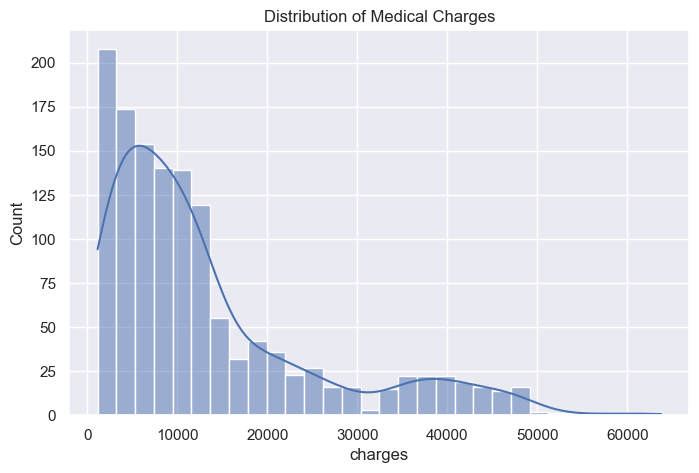

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

In [5]:
# target variable (charges) distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Medical Charges")
plt.show()
df['charges'].describe()

Right-skewed -> 일부 high-cost 환자가 리스크 좌우

mean: 13270, median: 9382 -> mean > median = 소수의 고비용 환자가 평균을 끌어올리고 있음.

그러면 high cost를 평균, 퍼센타일, z-score 중 어떤 걸로 정의할지를 정해야함.

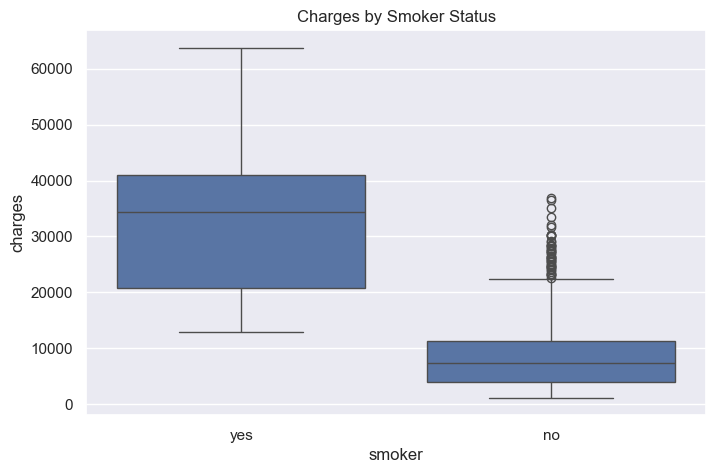

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges by Smoker Status")
plt.show()

df.groupby('smoker')['charges'].mean()


흡연 여부가 비용에 미치는 영향 확인 -> smoker가 압도적으로 high-risk.

non-smoker 평균: 8434, smoker 평균: 32050 -> 약 4배 차이

분포도 자체도 다름: smoker는 특정 몇 명이 비싼게 아니라 그 그룹 전체가 비싸고 non-smoker 그룹은 대부분 낮은 구간에 위치하고 특정 몇 명이 outlier를 형성.

-> 띠라서 *"right tail의 대부분은 smoker가 만든다"*는 결론을 내릴 수 있음.

-> **non-smoker = low risk pool, smoker = high risk pool**

-> 만약 두 그룹으로부터 같은 premium을 받는다면 smoker 그룹에 있어 보험사가 큰 손실을 얻는다. 따라서 *"risk-based pricing이 필수"*라고 보여짐. 즉, smoker에게 더 높은 premium을 받아야한다.

But, 그러면 fairness의 문제가 발생한다. smoker에게 premium을 더 받으면 economically correct하지만 smoker 그룹에 대한 차별로 이어지는지가 쟁점이 되기 때문이다.

그러면 smoker x BMI, smoker x age를 통해 smoker 내부에서도 차이가 있는지 확인하자.

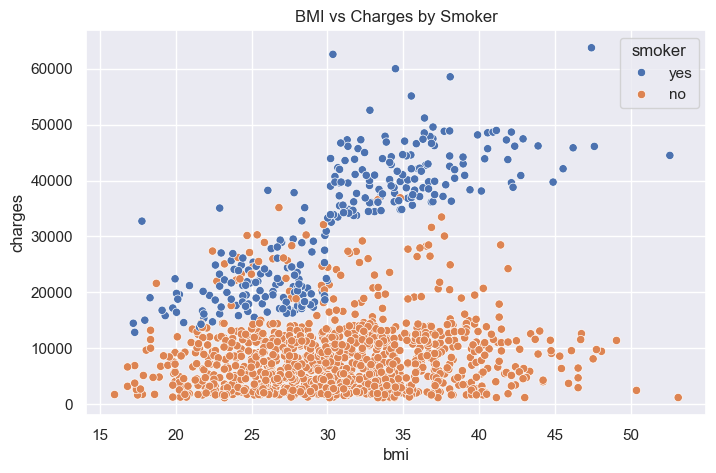

/var/folders/sl/8k4sw_117653bz3ws4wjv9940000gn/T/ipykernel_83646/4097296966.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('bmi_group')['charges'].mean()


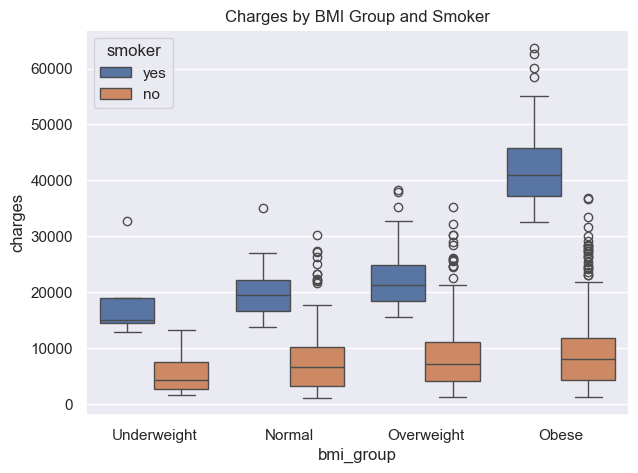

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title("BMI vs Charges by Smoker")
plt.show()

df['bmi_group'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100],
                         labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

df.groupby('bmi_group')['charges'].mean()

plt.figure(figsize=(7,5))
sns.boxplot(x='bmi_group', y='charges', hue='smoker', data=df)
plt.title("Charges by BMI Group and Smoker")
plt.show()

BMI는 smoker일 때만 강력하게 작용하는 변수 -> BMI는 dependent이므로 interaction effect 존재함을 알 수 있다.

BMI 그룹을 나눈 그래프에 따르면 obese smoker의 median이 +40k로 최상위 비용을 차지한다. 따라서, **obese + smoker = extreme risk cluster**이라고 결론 내릴 수 있다.

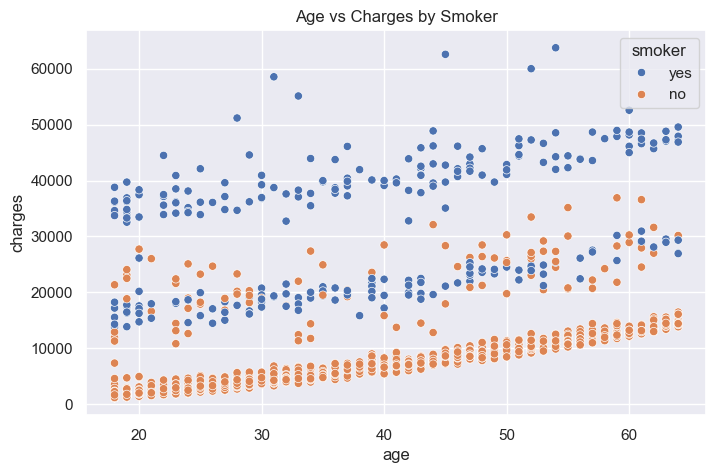

/var/folders/sl/8k4sw_117653bz3ws4wjv9940000gn/T/ipykernel_83646/4124872605.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_group', 'smoker'])['charges'].mean().unstack()


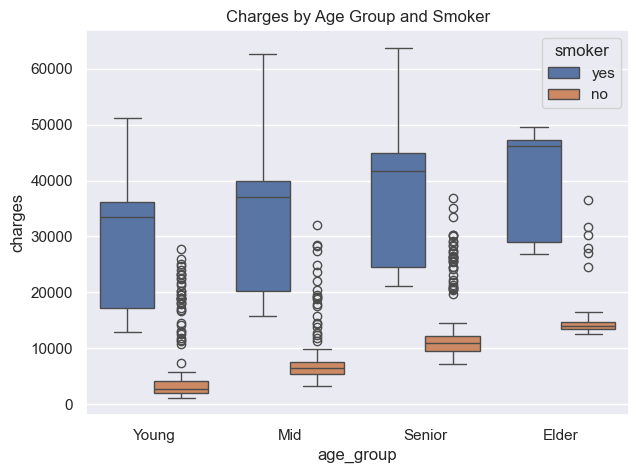

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title("Age vs Charges by Smoker")
plt.show()

df['age_group'] = pd.cut(df['age'],
                        bins=[0, 30, 45, 60, 100],
                        labels=['Young', 'Mid', 'Senior', 'Elder'])

df.groupby(['age_group', 'smoker'])['charges'].mean().unstack()

plt.figure(figsize=(7,5))
sns.boxplot(x='age_group', y='charges', hue='smoker', data=df)
plt.title("Charges by Age Group and Smoker")
plt.show()

나이는 모든 사람에게 영향이 있어 두 그룹이 같은 양상을 보이나, smoker 그룹이 non-smoker 그룹보다 두 배 가량 charge가 높다.

Smoker 내부만 따로 보면,

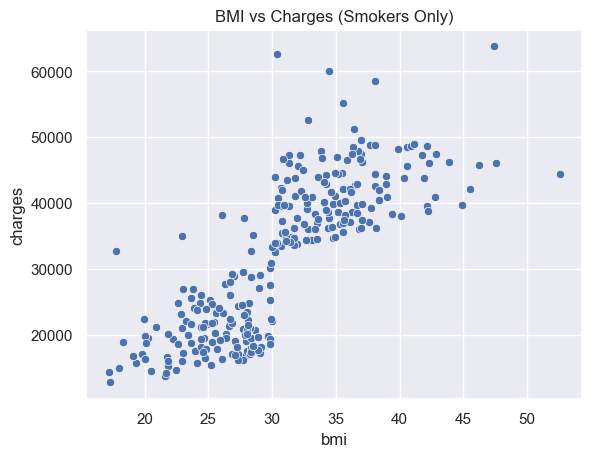

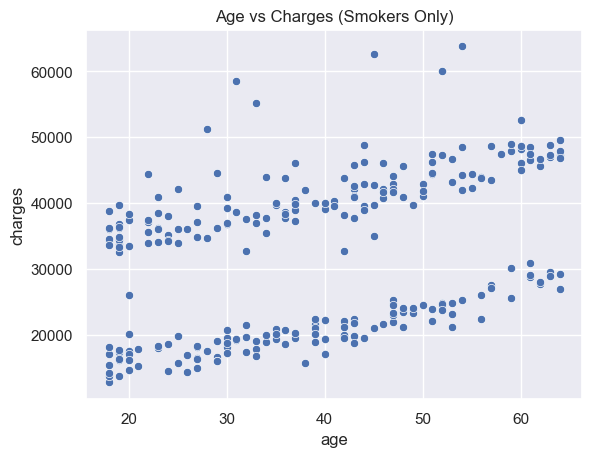

In [9]:
smoker_df = df[df['smoker'] == 'yes']

sns.scatterplot(x='bmi', y='charges', data=smoker_df)
plt.title("BMI vs Charges (Smokers Only)")
plt.show()

sns.scatterplot(x='age', y='charges', data=smoker_df)
plt.title("Age vs Charges (Smokers Only)")
plt.show()

결론적으로는 **higher BMI = higher risk, higher age = higher risk**.

첫번째 그래프를 보면 BMI=30을 기준으로 charges가 급격하게 변화 (discontinuity). -> BMI는 단순히 값을 키우는 변수가 아니라 리스크 상태를 바꾸는 *threshold*처럼 작용함. 따라서 단순 correlation이 아니라 regime change (구간 변화)로 보아야 맞다. 추후에 linear model 하나가 아닌 구간 별로 다른 함수가 필요할 가능성.

또한, BMI=30, chares=30k를 기준으로 두 그룹으로 나뉜 것을 볼 수 있는데, 이 두 그룹이 두번째 그래프에서의 두개의 층이라고 보여진다.

모든 변수들과 구해진 interactive 변수 조합을 사용해 risk 추정치를 수식으로 표현하면,

$Risk \approx \beta_0 + \beta_1 \cdot smoker + \beta_2 \cdot Age + \beta_3 \cdot BMI + \beta_4 \cdot (smoker \times Age) + \beta_5 \cdot (smoker \times BMI) + \beta_6 \cdot \mathbf{1}(BMI \ge 30) + \beta_7 \cdot (smoker \times \mathbf{1}(BMI \ge 30))$


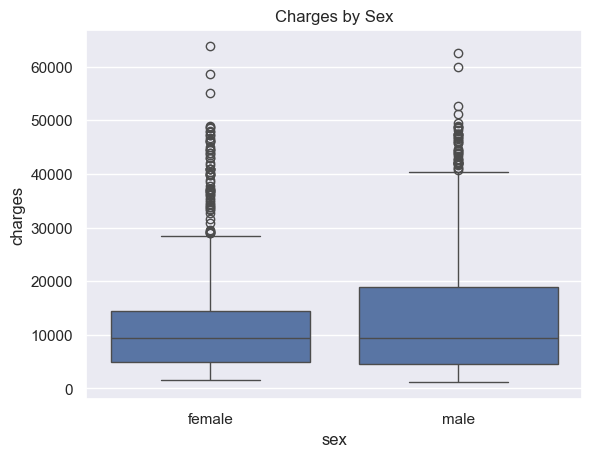

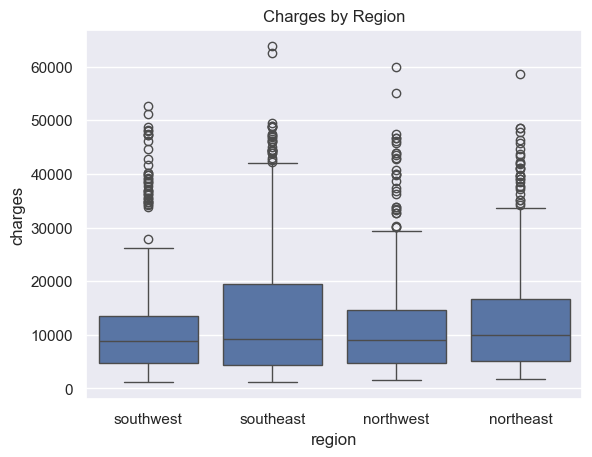

In [10]:
sns.boxplot(x='sex', y='charges', data=df)
plt.title("Charges by Sex")
plt.show()

sns.boxplot(x='region', y='charges', data=df)
plt.title("Charges by Region")
plt.show()

sex: median 거의 비슷, 분포도 거의 겹침, extreme 값도 양쪽에 다 존재. 따라서 비용을 설명하는 주요 변수는 아님.
region: 약간의 차이는 존재하나 구조적으로 나뉘어 보이지 않음. explanatory power 없음.

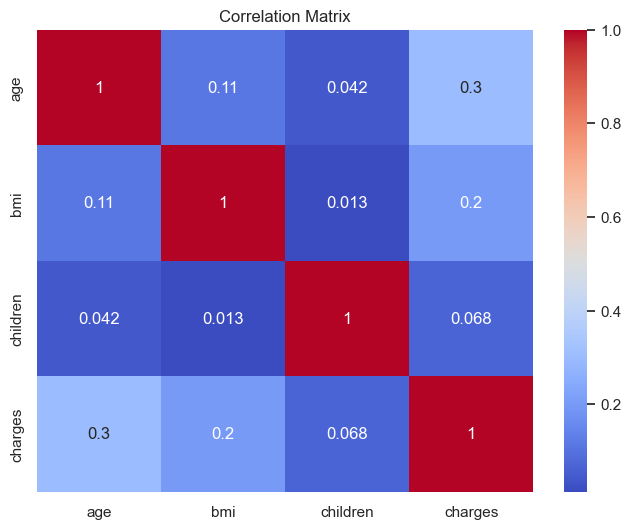

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Why does fairness matter? ##
### Point 1: predictive power ###
"이 변수가 실제 결과를 잘 설명하는가?"
### Point 2: ethical justification ###
"이 변수를 기준으로 차이를 두는 것이 사회적으로/법적으로 허용되는가?"
1) 행동기반: 개인이 선택한 것 i.e 흡연 여부, 운동 습관, 운전 기록
2) 선천적/민감 속성: 개인이 선택할 수 없는 것 i.e 성별, 인종, 종교 => 법적으로 사용 금지인지 꼭 확인할 것!
### Point 3: causality ###
"이 변수가 '직접적인 원인'인가 아니면 단순 상관관계인가?"

i.e region은 비용과 상관 있지만 이는 의료비 구조, 환경, 접근성 때문이지 region 자체가 원인은 아님. 즉, proxy variable일 가능성이 있다.

## Then how do we determine proxy variable? ##
**Proxy variable**: 겉으로는 괜찮아 보이지만 실제로는 민감한 속성을 대신하는 변수 i.e zip code -> race proxy, school name -> socio-economic proxy
1) 도메인 지식으로 1차 필터: 이 변수가 다른 민감 속성과 연결될 가능성이 있는가?

    i.e region -> 생활 수준, 의료 접근성, 인종 분포 -> proxy 가능성 있음.
    smoker -> 개인 행동 -> proxy 가능성 낮음.

2) 데이터 기반 상관관계 확인: 상관관계 강하면 proxy 의심

3) 조건부 분석: 다른 변수를 통제했을 때도 영향이 남는가?

    i.e region이 charges에 영향 있음. 그런데 smoker, BMI, age를 통제했을 때 영향이 사라지면 region은 진짜 원인이 아니라 proxy.